# ANÁLISE EXPLORATÓRIA BIVARIADA - SIA/SUS
**Foco:** Relações de dependência, covariância e diferenças entre grupos.

In [2]:
import os
import sys
import numpy as np

# Adicionar o diretório raiz do projeto ao path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from dotenv import load_dotenv
from src.analysis.data_quality import DataQualityAuditor
from src.analysis.bivariate_analyzer import BivariateAnalyzer

load_dotenv()
auditor = DataQualityAuditor(os.getenv("DB_URL"))
df = auditor.fetch_data()

bivariada = BivariateAnalyzer(df)

## 1. RELAÇÃO QUANTITATIVA (Quant x Quant)
**Objetivo:** Verificar se o volume de procedimentos explica o custo total.

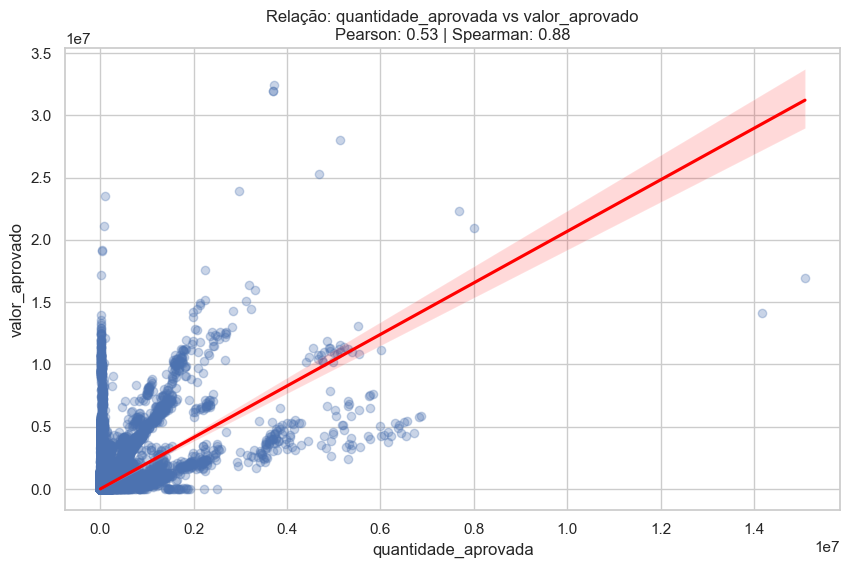

In [3]:
# Cruzando Quantidade Aprovada vs Valor Aprovado
bivariada.plot_scatter_with_correlation('quantidade_aprovada', 'valor_aprovado')

## 2. RELAÇÃO CATEGÓRICA vs QUANTITATIVA (Quali x Quant)
**Objetivo:** Identificar quais subgrupos possuem maior variabilidade e custo mediano.

c:\Projetos\projeto-datasus-sia\src\analysis\bivariate_analyzer.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x=quant_col, y=cat_col, palette="Set2")


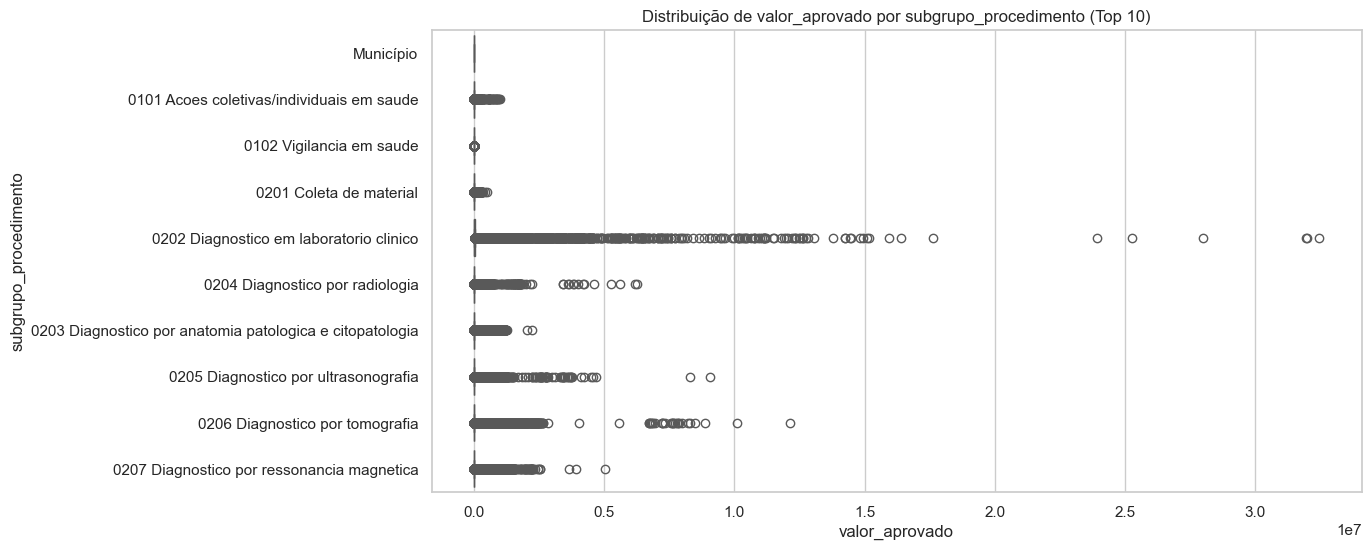

In [4]:
# Valor Aprovado por Subgrupo de Procedimento
bivariada.plot_box_by_category('valor_aprovado', 'subgrupo_procedimento')

## 3. MATRIZ DE COVARIAÇÃO
**Objetivo:** Visualizar a força das associações entre todas as métricas numéricas.

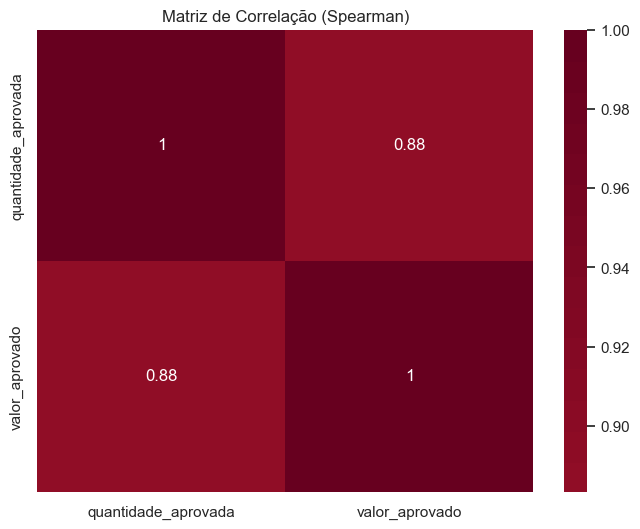

In [5]:
bivariada.plot_heatmap_correlation(['quantidade_aprovada', 'valor_aprovado'])

## 4. ANÁLISE TEMPORAL BIVARIADA
**Objetivo:** Verificar a evolução do valor médio ao longo dos 25 meses.

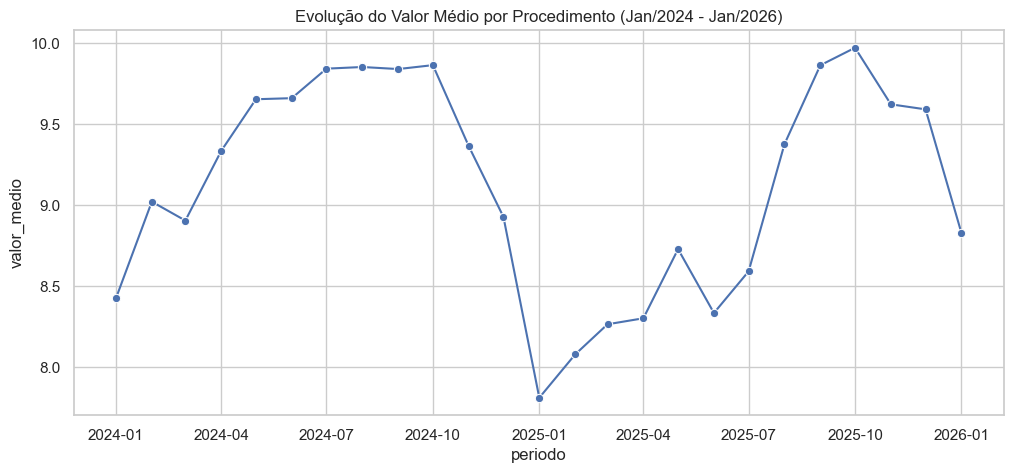

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

df['valor_medio'] = df['valor_aprovado'] / df['quantidade_aprovada']
df['valor_medio'] = df['valor_medio'].replace([np.inf, -np.inf], 0).fillna(0)

df_time = df.groupby('periodo')['valor_medio'].mean().reset_index()
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_time, x='periodo', y='valor_medio', marker='o')
plt.title("Evolução do Valor Médio por Procedimento (Jan/2024 - Jan/2026)")
plt.savefig("../docs/reports/figures/bivariada_temporal_media.png")
plt.show()